In [1]:
import polars as pl 
from pathlib import Path
from yaml import safe_load
import seaborn as sns 
import numpy as np

sns.set_style('whitegrid')

In [2]:
res_path = Path(
    "/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/training_curve"
)

cols_to_read = ["ID", "ground_truth", "prediction"]


def load_data(res_path):

    dfs = []

    for fpath in res_path.rglob("*.parquet"):

        config_path = fpath.parent / 'config.yml'
        with config_path.open() as config_file:
            config = safe_load(config_file)

        df = pl.read_parquet(fpath, columns=cols_to_read).with_columns(
                pl.lit(fpath.parent.parent.name).alias("benchmark"),
                pl.lit(fpath.parent.parent.parent.name).alias("cohort"),
                (pl.col("ground_truth") == pl.col("prediction"))
                .cast(pl.Int8)
                .alias("correct"),
                pl.lit(config['training_steps']).alias('training_steps'),
                pl.lit(config['run_readable_name']).alias('model')
            )

        dfs.append(df)


    return pl.concat(dfs)

In [3]:
df = load_data(res_path)

In [4]:
df = df.filter(pl.col('benchmark').is_in(['test_mci','test_np_mixed','test_np']).not_())

In [5]:
df.select(pl.col('benchmark').unique())

benchmark
str
"""test_ftld"""
"""test_cog"""
"""test_pet"""
"""test_csf"""
"""test_dat"""
"""test_etpr"""
"""test_np_one"""


In [6]:
df

ID,ground_truth,prediction,benchmark,cohort,correct,training_steps,model
str,str,str,str,str,i8,i32,str
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
"""sub-CLB00196""","""A""","""A""","""test_cog""","""brainlat_test""",1,0,"""Qwen2.5-7B-Instruct"""
…,…,…,…,…,…,…,…
"""131120""","""B""","""B""","""test_dat""","""ppmi_test""",1,1000,"""NACC-3B-OS-SCE-1000"""
"""131120""","""B""","""B""","""test_dat""","""ppmi_test""",1,1000,"""NACC-3B-OS-SCE-1000"""
"""131120""","""B""","""A""","""test_dat""","""ppmi_test""",0,1000,"""NACC-3B-OS-SCE-1000"""


In [112]:
acc = df.filter(pl.col('model').str.contains('NACC')).group_by('training_steps','cohort','benchmark').agg(pl.col('correct').mean()).sort('training_steps')

acc = acc.with_columns(
    pl.when(pl.col('cohort').str.contains('nacc')).then(pl.lit('Internal validation\n(NACC)')).otherwise(pl.lit('External validation\n(All other cohorts)')).alias('in_distribution')
)

acc

training_steps,cohort,benchmark,correct,in_distribution
i32,str,str,f64,str
100,"""nifd_test""","""test_ftld""",0.428082,"""External validation (All other…"
100,"""nacc_test_updated""","""test_pet""",0.638614,"""Internal validation (NACC)"""
100,"""ppmi_test""","""test_etpr""",0.541935,"""External validation (All other…"
100,"""ppmi_test""","""test_cog""",0.516,"""External validation (All other…"
100,"""nacc_test_updated""","""test_cog""",0.694,"""Internal validation (NACC)"""
…,…,…,…,…
1491,"""nifd_test""","""test_cog""",0.639041,"""External validation (All other…"
1491,"""nifd_test""","""test_ftld""",0.534932,"""External validation (All other…"
1491,"""ppmi_test""","""test_etpr""",0.604659,"""External validation (All other…"


In [113]:
base3 = (
    df.filter(pl.col("model") == "Qwen2.5-3B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(
        pl.col("correct").mean().alias("accuracy"),
    )
)

n_boot = 1000
q3b_bsamples = np.array([base3.sample(fraction=1,with_replacement=True).select(pl.col('accuracy').mean()).item() for _ in range(n_boot)])

q3b_mean = q3b_bsamples.mean()
q3b_low = np.quantile(q3b_bsamples,0.025)
q3b_high = np.quantile(q3b_bsamples,0.975)

In [114]:
base7 = (
    df.filter(pl.col("model") == "Qwen2.5-7B-Instruct")
    .group_by("cohort", "benchmark")
    .agg(
        pl.col("correct").mean().alias("accuracy"),
    )
)

n_boot = 1000
q7b_bsamples = np.array([base7.sample(fraction=1,with_replacement=True).select(pl.col('accuracy').mean()).item() for _ in range(n_boot)])

q7b_mean = q7b_bsamples.mean()
q7b_low = np.quantile(q7b_bsamples,0.025)
q7b_high = np.quantile(q7b_bsamples,0.975)

Text(0.5, 29.140625, 'Training step')

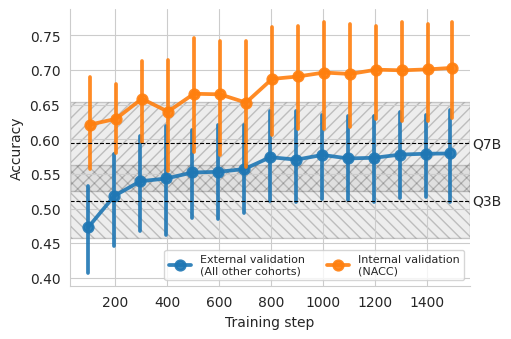

In [121]:
g = sns.catplot(
    acc.to_pandas(),
    x='training_steps',
    y='correct',
    kind='point',
    hue='in_distribution',
    native_scale=True,
    errorbar=('ci',95),
    estimator='mean',
    height=3.5,
    aspect=1.4,
    alpha=0.9, 
    # capsize=0.2,
    dodge=0.07,
    legend_out=False
)

g.refline(y=q3b_mean,color='black',linewidth=0.8)
g.refline(y=q7b_mean,color='black',linewidth=0.8)

# Add text annotations
for ax in g.axes.flat:

    # ax.axhspan(q3b_low, q3b_high, alpha=0.2, color='black', zorder=0)
    # ax.axhspan(q7b_low, q7b_high, alpha=0.2, color='black', zorder=0)
    ax.axhspan(q3b_low, q3b_high, alpha=0.2,  hatch='\\\\\\', edgecolor='black', facecolor='darkgray', zorder=0)
    ax.axhspan(q7b_low, q7b_high, alpha=0.2,  hatch='///', edgecolor='black', facecolor='darkgray', zorder=0)
    
    ax.text(
        ax.get_xlim()[1] + 10,
        q3b_mean,
        "Q3B",
        verticalalignment="center",
        horizontalalignment="left",
        fontsize=10,
    )
    ax.text(
        ax.get_xlim()[1] + 10,
        q7b_mean,
        "Q7B",
        verticalalignment="center",
        horizontalalignment="left",
        fontsize=10,
    )
    ax.set_ylabel("Accuracy")

    ax.legend(ncols=3,fontsize=8)

ax.set_xlabel("Training step")

In [122]:
g.savefig('../figures/training_curve_all_averaged.pdf')

Text(24.000000000000007, 0.5, 'Accuracy')

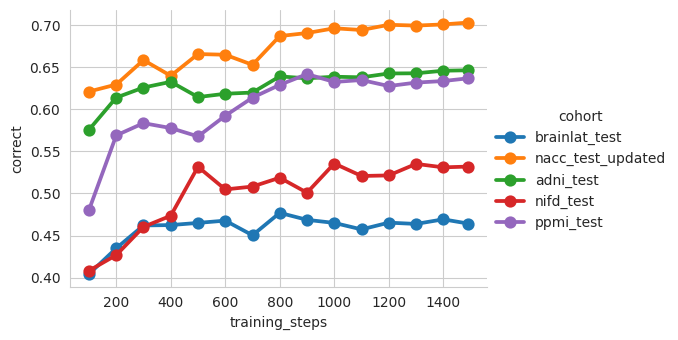

In [11]:
g = sns.catplot(
    acc.to_pandas(),
    x='training_steps',
    hue='cohort',
    y='correct',
    kind='point',
    native_scale=True,
    errorbar=None,
    height=3.5,
    aspect=1.5,
)

ax.set_xlabel("Training step")
ax.set_ylabel("Accuracy")

Text(24.000000000000007, 0.5, 'Accuracy')

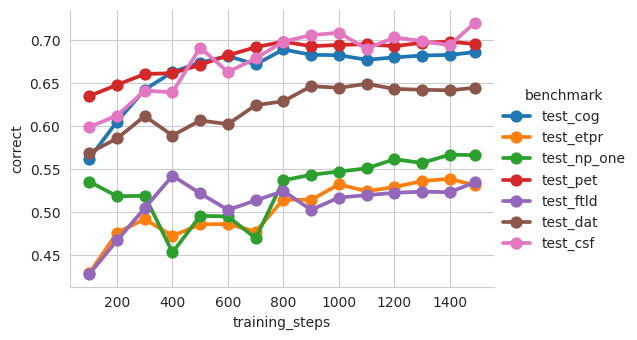

In [12]:
g = sns.catplot(
    acc.to_pandas(),
    x='training_steps',
    hue='benchmark',
    y='correct',
    kind='point',
    native_scale=True,
    errorbar=None,
    height=3.5,
    aspect=1.5,
)

ax.set_xlabel("Training step")
ax.set_ylabel("Accuracy")

Text(24.000000000000007, 0.5, 'Accuracy')

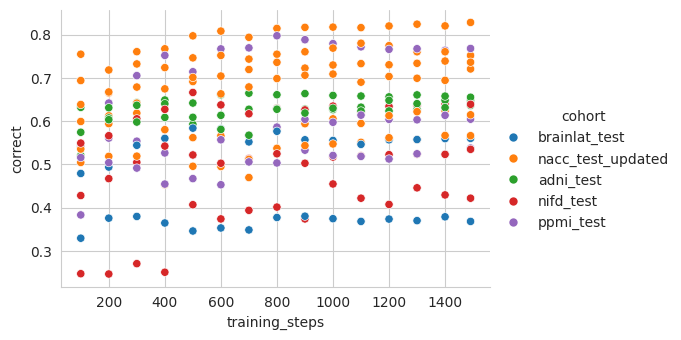

In [13]:
g = sns.relplot(
    acc.to_pandas(),
    x='training_steps',
    hue='cohort',
    y='correct',
    kind='scatter',
    # native_scale=True,
    # errorbar=None,
    height=3.5,
    aspect=1.5,
)

ax.set_xlabel("Training step")
ax.set_ylabel("Accuracy")

In [21]:
import matplotlib.pyplot as plt
import numpy as np

In [42]:
acc

training_steps,cohort,benchmark,correct,in_distribution
i32,str,str,f64,str
100,"""brainlat_test""","""test_cog""",0.479091,"""External validation"""
100,"""nacc_test_updated""","""test_cog""",0.694,"""Internal validation"""
100,"""adni_test""","""test_cog""",0.5744,"""External validation"""
100,"""nacc_test_updated""","""test_etpr""",0.5046,"""Internal validation"""
100,"""adni_test""","""test_etpr""",0.5208,"""External validation"""
…,…,…,…,…
1491,"""ppmi_test""","""test_dat""",0.5378,"""External validation"""
1491,"""nifd_test""","""test_ftld""",0.534932,"""External validation"""
1491,"""nifd_test""","""test_cog""",0.639041,"""External validation"""



External validation
(All other cohorts) fit diagnostics:
  asymptote = 0.6157 ± 0.0035
  slope = -1.3903 ± 0.0858
  alpha = 0.5000 (fixed)
  R² = 0.9563
  Relative slope uncertainty: 6.2%
  (fit excludes first 1 points)

Internal validation
(NACC) fit diagnostics:
  asymptote = 0.7439 ± 0.0096
  slope = -1.7190 ± 0.2349
  alpha = 0.5000 (fixed)
  R² = 0.8170
  Relative slope uncertainty: 13.7%
  (fit excludes first 1 points)


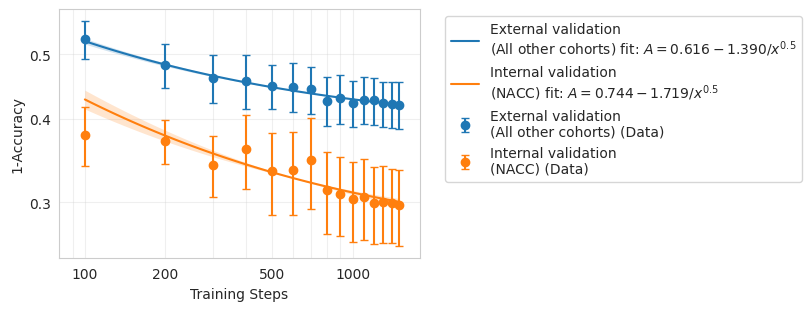

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.ticker import FuncFormatter

def plot_accuracy_with_powerlaw_fit(df, step_col='training_steps', 
                                     group_col='in_distribution', 
                                     accuracy_col='correct',
                                     n_bootstrap=1000, figsize=(10, 6),
                                     skip_first_k=0):
    """
    Plot log-log accuracy curves with power law fits for different groups.
    Fits the model: accuracy = asymptote + slope / steps^0.5
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    step_col : str
        Name of column containing training steps
    group_col : str
        Name of column containing group labels
    accuracy_col : str
        Name of column containing accuracy values
    n_bootstrap : int
        Number of bootstrap samples for confidence intervals (not currently used)
    figsize : tuple
        Figure size (width, height)
    skip_first_k : int
        Number of initial points to skip when fitting (default: 0)
        
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    def bootstrap_ci(data, n_bootstrap=1000, ci=95):
        """Calculate bootstrap confidence interval for mean."""
        means = []
        for _ in range(n_bootstrap):
            sample = np.random.choice(data, size=len(data), replace=True)
            means.append(np.mean(sample))
        lower = np.percentile(means, (100 - ci) / 2)
        upper = np.percentile(means, 100 - (100 - ci) / 2)
        return lower, upper
    
    # Get unique values of group column
    groups = df[group_col].unique()
    colors = ['C0', 'C1', 'C2', 'C3', 'C4']  # Support up to 5 groups
    
    fig, ax = plt.subplots(figsize=figsize, layout='constrained')
    
    all_steps = []  # Track all steps to set x-axis limits later
    
    # Fixed alpha = 0.5
    alpha_fixed = 0.5
    
    for idx, group in enumerate(groups):
        # Filter data for this group
        group_data = df[df[group_col] == group]
        
        # Get unique training steps
        steps = sorted(group_data[step_col].unique())
        
        # Calculate mean accuracy and standard error for each step
        mean_accuracy = []
        std_error = []
        
        for step in steps:
            step_data = group_data[group_data[step_col] == step][accuracy_col].values
            mean_acc = np.mean(step_data)
            se = np.std(step_data, ddof=1) / np.sqrt(len(step_data))  # Standard error
            
            mean_accuracy.append(mean_acc)
            std_error.append(se)
        
        step = np.array(steps)
        all_steps.extend(steps)  # Collect all steps
        mean_accuracy = np.array(mean_accuracy)
        std_error = np.array(std_error)
        
        # Plot data with error bars (standard error)
        ax.errorbar(step, 1 - mean_accuracy, 
                     yerr=std_error,
                     linestyle='none', marker='o', label=f'{group} (Data)', 
                     color=colors[idx], capsize=3, zorder=3)
        
        # Fit the power law model: accuracy = asymptote + slope / steps^0.5
        try:
            # Two-parameter model with fixed alpha = 0.5
            def power_law_2param(x, asymptote, slope):
                return asymptote + slope / (x ** alpha_fixed)
            
            # Skip first k points for fitting if requested
            step_fit_data = step[skip_first_k:]
            mean_accuracy_fit_data = mean_accuracy[skip_first_k:]
            
            first_step = step_fit_data[0]
            last_step = step_fit_data[-1]
            first_acc = mean_accuracy_fit_data[0]
            last_acc = mean_accuracy_fit_data[-1]
            min_acc = min(mean_accuracy_fit_data)
            
            # Initial guesses
            asymptote_guess = last_acc
            slope_guess = (first_acc - asymptote_guess) * (first_step ** alpha_fixed)
            
            p0 = [asymptote_guess, slope_guess]
            bounds = ([min_acc, -10], [1.0, 0])
            
            # Fit the model using only the subset of data
            popt, pcov = curve_fit(power_law_2param, step_fit_data, mean_accuracy_fit_data, 
                                   p0=p0, bounds=bounds, maxfev=20000)
            asymptote, slope = popt
            
            # Calculate parameter uncertainties
            perr = np.sqrt(np.diag(pcov))
            asymptote_err, slope_err = perr
            
            # Print fit diagnostics
            r_squared = 1 - np.sum((mean_accuracy_fit_data - power_law_2param(step_fit_data, asymptote, slope))**2) / np.sum((mean_accuracy_fit_data - np.mean(mean_accuracy_fit_data))**2)
            print(f"\n{group} fit diagnostics:")
            print(f"  asymptote = {asymptote:.4f} ± {asymptote_err:.4f}")
            print(f"  slope = {slope:.4f} ± {slope_err:.4f}")
            print(f"  alpha = {alpha_fixed:.4f} (fixed)")
            print(f"  R² = {r_squared:.4f}")
            print(f"  Relative slope uncertainty: {abs(slope_err/slope)*100:.1f}%")
            if skip_first_k > 0:
                print(f"  (fit excludes first {skip_first_k} points)")
            
            # Generate fitted line over full range
            step_fit = np.logspace(np.log10(step.min()), np.log10(step.max()), 100)
            accuracy_fit = power_law_2param(step_fit, asymptote, slope)
            error_fit = 1 - accuracy_fit
            
            # Format the label with proper sign handling
            if slope >= 0:
                sign_str = "+"
                slope_str = f"{slope:.3f}"
            else:
                sign_str = ""
                slope_str = f"{slope:.3f}"
            
            # Plot fitted line
            label_text = f'{group} fit: $A = {asymptote:.3f} {sign_str} {slope_str}/x^{{0.5}}$'
            ax.loglog(step_fit, error_fit, color=colors[idx], linestyle='-', 
                       label=label_text, zorder=2)
            
            # Calculate uncertainty band
            accuracy_upper = power_law_2param(step_fit, asymptote + asymptote_err, slope - slope_err)
            accuracy_lower = power_law_2param(step_fit, asymptote - asymptote_err, slope + slope_err)
            error_upper_fit = 1 - accuracy_lower
            error_lower_fit = 1 - accuracy_upper
            
            # Plot uncertainty band (no label)
            ax.fill_between(step_fit, error_lower_fit, error_upper_fit, 
                             alpha=0.2, color=colors[idx], 
                             zorder=1, linewidth=0)
        
        except Exception as e:
            print(f"Warning: Could not fit power law for group {group}: {e}")
            continue
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('1-Accuracy')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which='both', alpha=0.3)
    
    # Add minor ticks
    ax.minorticks_on()
    
    # Set x-axis limits to just slightly beyond the data range
    all_steps = np.array(all_steps)
    x_min = all_steps.min() * 0.8
    x_max = all_steps.max() * 1.2
    ax.set_xlim(x_min, x_max)
    
    # Set appropriate x-axis ticks based on data range
    xticks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
    xticks = [x for x in xticks if x_min <= x <= x_max]
    if xticks:
        ax.set_xticks(xticks, minor=False)
        ax.set_xticklabels([str(x) for x in xticks])
    
    # Format y-axis as decimal numbers instead of scientific notation
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2g}'))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: f'{y:.2g}'))
    
    return fig, ax


# Example usage:
# fig, ax = plot_accuracy_with_powerlaw_fit(acc)
# fig, ax = plot_accuracy_with_powerlaw_fit(acc, skip_first_k=2)  # Skip first 2 points
# plt.show()  # Call this if you want to display the plot

fig, ax = plot_accuracy_with_powerlaw_fit(acc.to_pandas(),figsize=(8,3),skip_first_k=1)